# Exploratory Data Analysis

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

processed_path = '../Data/Processed/'
master = pd.read_csv(processed_path + 'master_dataset.csv')

print('Master dataset shape:', master.shape)
print(master.head(3).to_string())

Master dataset shape: (1866, 96)
   Season             Name Team   W   L  SV   G  GS     IP       K/9      BB/9      HR/9     BABIP        LOB%          GB%        HR/FB       ERA      xERA       FIP      xFIP       WAR         FA%         FC%       FS%  FO%         SI%         SL%         CU%        KC%      EP%         CH%  SC%  KN%        vFA        vFC        vFS  vFO        vSI        vSL        vCU        vKC        vEP        vCH  vSC  vKN      FA-X      FC-X      FS-X  FO-X       SI-X      SL-X      CU-X      KC-X      EP-X      CH-X  SC-X  KN-X       FA-Z      FC-Z      FS-Z  FO-Z      SI-Z      SL-Z      CU-Z       KC-Z      EP-Z      CH-Z  SC-Z  KN-Z       FA-SPN       FC-SPN      FS-SPN  FO-SPN       SI-SPN       SL-SPN       CU-SPN  KC-SPN  EP-SPN      CH-SPN  SC-SPN  KN-SPN  K/BB     K%    BB%  K-BB%  WHIP  ERA-  FIP-  xFIP-  SIERA League  Rank  Vote_Pts  1st_Place  Share  CY_winner
0    2025  Clayton Kershaw  LAD  11   2   0  22  22  111.2  6.770149  2.820896  0.644776  

## Section 1 - Overall DataSet Understanding

### Summary Statistics

In [16]:
# Basic summary statistics
print('Master dataset shape:', master.shape)
print()
print('Summary statistics for key performance columns:')
# All performance columns
perf_cols = ['ERA', 'xERA', 'FIP', 'xFIP', 'SIERA', 'WAR', 
             'K/9', 'BB/9', 'HR/9', 'K%', 'BB%', 'K-BB%', 'K/BB',
             'WHIP', 'BABIP', 'LOB%', 'GB%', 'HR/FB',
             'ERA-', 'FIP-', 'xFIP-', 'IP', 'W', 'L']

print(master[perf_cols].describe().round(3))

Master dataset shape: (1866, 96)

Summary statistics for key performance columns:
            ERA      xERA       FIP      xFIP     SIERA       WAR       K/9  \
count  1866.000  1866.000  1866.000  1866.000  1866.000  1866.000  1866.000   
mean      4.272     4.394     4.277     4.214     4.266     1.750     8.163   
std       1.154     0.943     0.914     0.708     0.668     1.539     1.766   
min       0.540     1.560     1.235     1.500     1.180    -1.636     2.797   
25%       3.484     3.768     3.686     3.753     3.830     0.613     6.934   
50%       4.188     4.315     4.238     4.228     4.295     1.497     8.036   
75%       4.919     4.971     4.821     4.696     4.730     2.561     9.262   
max       9.759     8.556     8.557     6.134     6.230     9.041    16.430   

           BB/9      HR/9        K%  ...     K-BB%      K/BB      WHIP  \
count  1866.000  1866.000  1866.000  ...  1866.000  1866.000  1866.000   
mean      2.941     1.263     0.215  ...     0.139     3.0

### Distribution plots key performance metrics

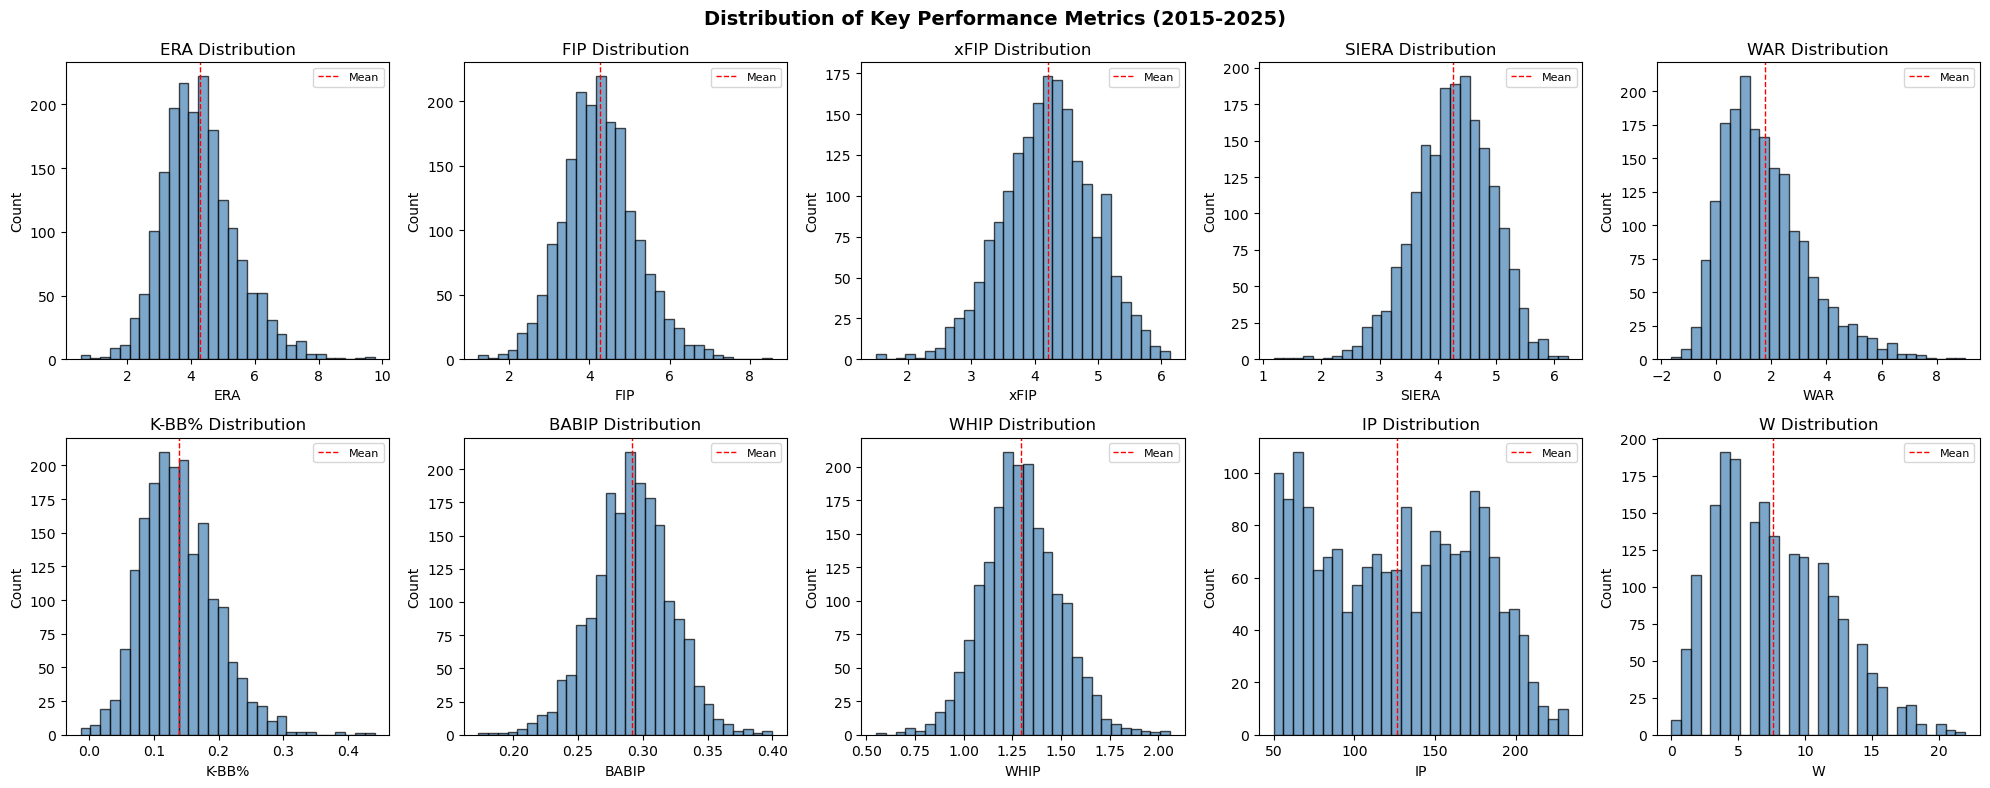

In [25]:
# Distribution plots for key performance features
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

features = ['ERA', 'FIP', 'xFIP', 'SIERA', 'WAR', 'K-BB%', 'BABIP', 'WHIP', 'IP', 'W']

for i, (feat, ax) in enumerate(zip(features, axes.flatten())):
    ax.hist(master[feat].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'{feat} Distribution')
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
    ax.axvline(master[feat].mean(), color='red', linestyle='--', linewidth=1, label='Mean')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of Key Performance Metrics (2015-2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../Outputs/distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### Outlier Detection

In [26]:
# Outlier detection using IQR for key performance metrics
perf_cols = ['ERA', 'FIP', 'xFIP', 'SIERA', 'WAR', 'K-BB%', 'BABIP', 'WHIP', 'IP', 'W']

outlier_summary = []
for col in perf_cols:
    Q1 = master[col].quantile(0.25)
    Q3 = master[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = master[(master[col] < lower) | (master[col] > upper)]
    outlier_summary.append({'Feature': col, 'Lower Bound': round(lower,2), 
                            'Upper Bound': round(upper,2), 'Outlier Count': len(outliers)})

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string())

  Feature  Lower Bound  Upper Bound  Outlier Count
0     ERA         1.33         7.07             41
1     FIP         1.98         6.52             37
2    xFIP         2.34         6.11             12
3   SIERA         2.48         6.08             13
4     WAR        -2.31         5.48             50
5   K-BB%        -0.02         0.29             25
6   BABIP         0.22         0.37             27
7    WHIP         0.80         1.80             26
8      IP       -46.75       296.85              0
9       W        -6.50        21.50              2


## Section 2 - Cy Young Prediction EDA

### Voters vs Non-voters vs Winners comparison Performance stats avg comparison & bar chart

In [27]:
# Section 2 - Cy Young Prediction EDA
voters = master[master['Share'] > 0]
non_voters = master[master['Share'] == 0]
winners = master[master['CY_winner'] == 1]

print(f'Total pitchers: {len(master)}')
print(f'Voters: {len(voters)} ({len(voters)/len(master)*100:.1f}%)')
print(f'Non-voters: {len(non_voters)} ({len(non_voters)/len(master)*100:.1f}%)')
print(f'Winners: {len(winners)}')
print()

perf_cols = ['ERA', 'FIP', 'xFIP', 'SIERA', 'WAR', 'K-BB%', 'BABIP', 'WHIP', 'IP', 'W']
comparison = pd.DataFrame({
    'All Pitchers': master[perf_cols].mean(),
    'Voters': voters[perf_cols].mean(),
    'Winners': winners[perf_cols].mean()
}).round(3)

print(comparison)

Total pitchers: 1866
Voters: 184 (9.9%)
Non-voters: 1682 (90.1%)
Winners: 22

       All Pitchers   Voters  Winners
ERA           4.272    2.785    2.282
FIP           4.277    3.078    2.723
xFIP          4.214    3.304    3.016
SIERA         4.266    3.382    3.063
WAR           1.750    4.555    5.832
K-BB%         0.139    0.215    0.250
BABIP         0.292    0.273    0.263
WHIP          1.295    1.036    0.940
IP          126.352  177.578  190.618
W             7.633   13.641   15.364


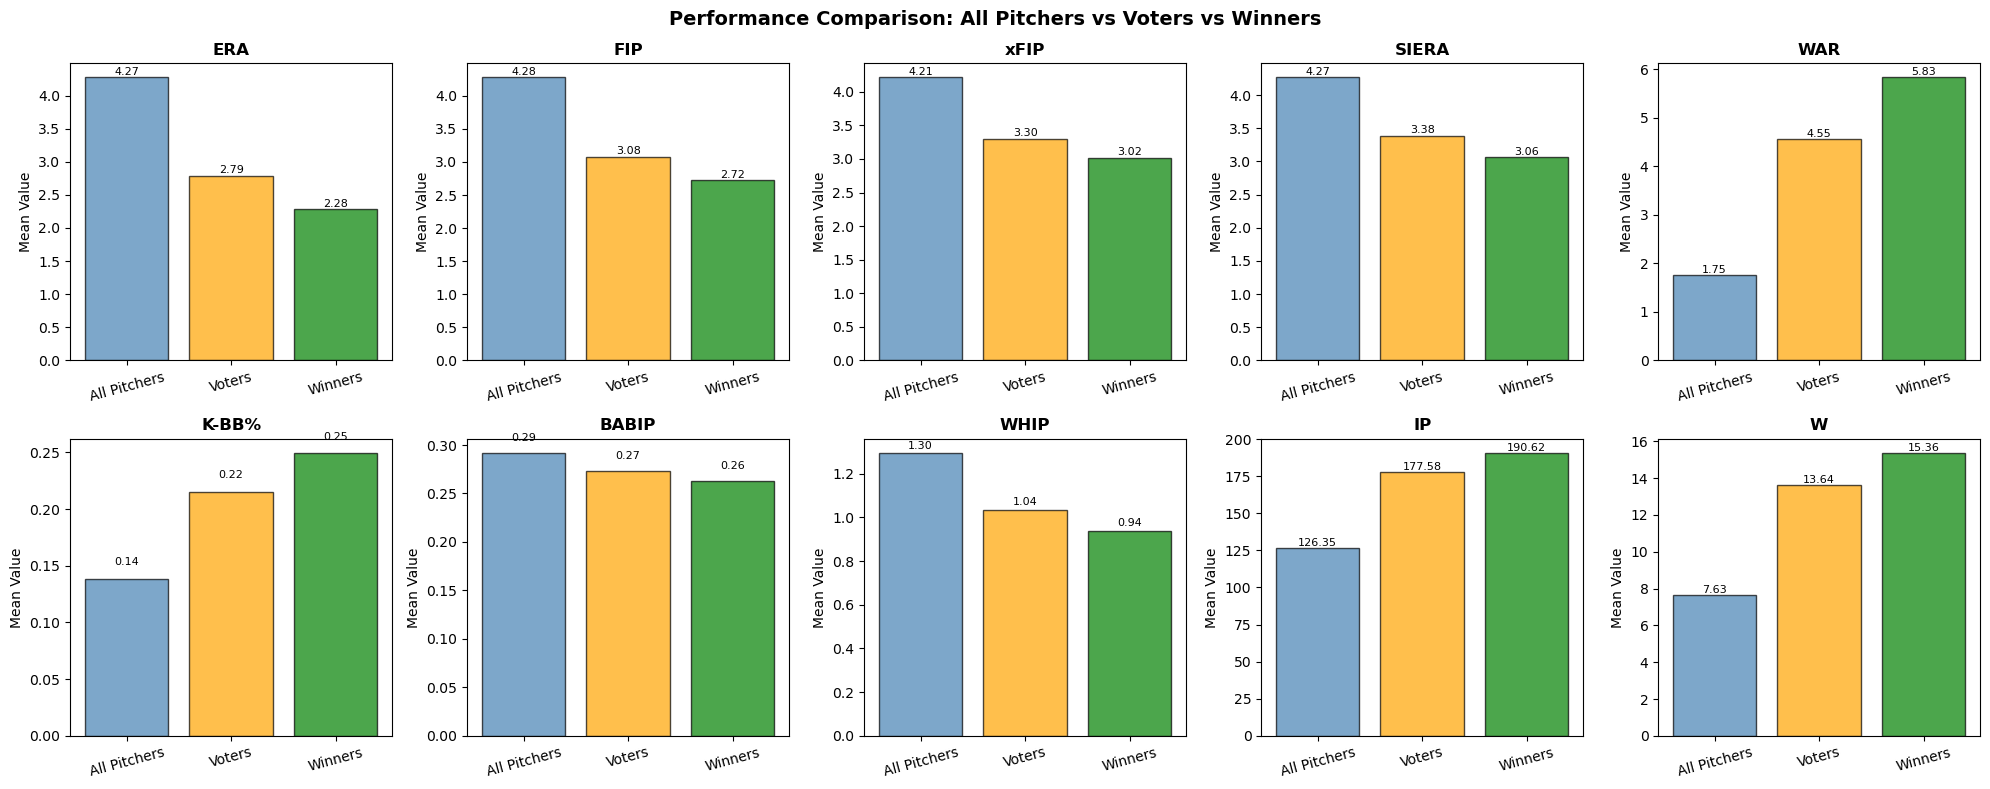

In [28]:
# Voters vs Non-voters vs Winners comparison bar chart
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

perf_cols = ['ERA', 'FIP', 'xFIP', 'SIERA', 'WAR', 'K-BB%', 'BABIP', 'WHIP', 'IP', 'W']
categories = ['All Pitchers', 'Voters', 'Winners']
colors = ['steelblue', 'orange', 'green']

for i, (feat, ax) in enumerate(zip(perf_cols, axes.flatten())):
    values = [master[feat].mean(), voters[feat].mean(), winners[feat].mean()]
    bars = ax.bar(categories, values, color=colors, edgecolor='black', alpha=0.7)
    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel('Mean Value')
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Performance Comparison: All Pitchers vs Voters vs Winners', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../Outputs/voters_vs_winners.png', dpi=150, bbox_inches='tight')
plt.show()

### Vote share distribution

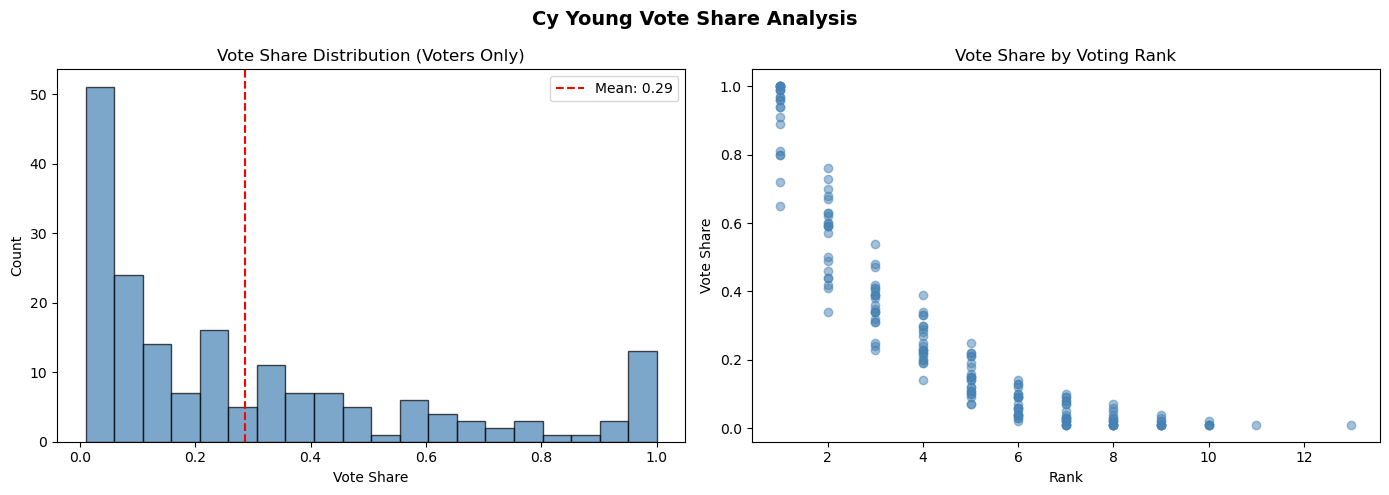

In [29]:
# Vote share distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All voters
axes[0].hist(voters['Share'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Vote Share Distribution (Voters Only)')
axes[0].set_xlabel('Vote Share')
axes[0].set_ylabel('Count')
axes[0].axvline(voters['Share'].mean(), color='red', linestyle='--', label=f'Mean: {voters["Share"].mean():.2f}')
axes[0].legend()

# Vote share by rank
axes[1].scatter(voters['Rank'], voters['Share'], alpha=0.5, color='steelblue')
axes[1].set_title('Vote Share by Voting Rank')
axes[1].set_xlabel('Rank')
axes[1].set_ylabel('Vote Share')

plt.suptitle('Cy Young Vote Share Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../Outputs/vote_share_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Correlation of performance features with vote share

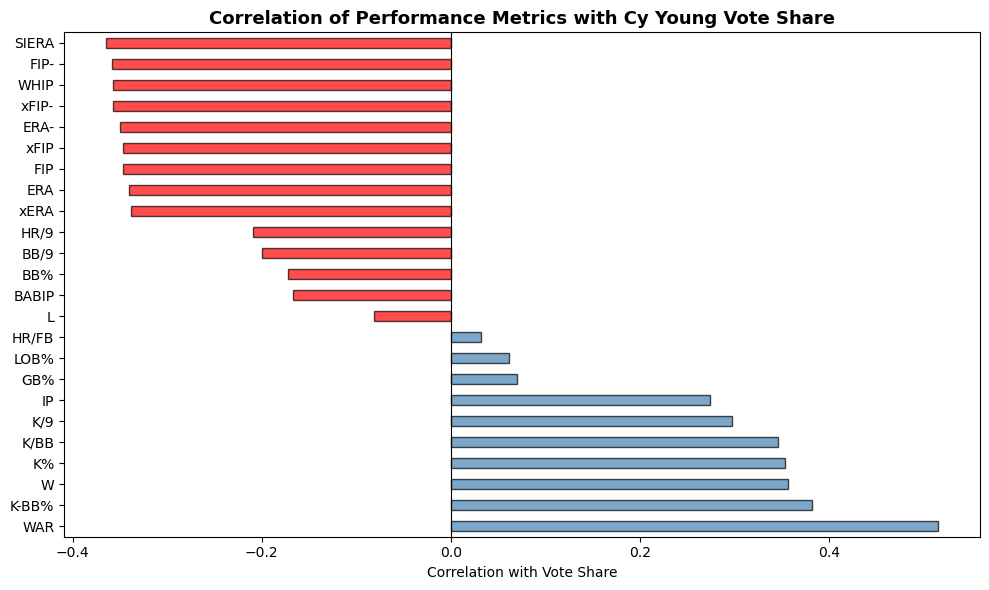

SIERA   -0.365057
FIP-    -0.357930
WHIP    -0.357714
xFIP-   -0.357247
ERA-    -0.349876
xFIP    -0.347159
FIP     -0.346282
ERA     -0.340556
xERA    -0.338585
HR/9    -0.209454
BB/9    -0.200083
BB%     -0.172274
BABIP   -0.166871
L       -0.081366
HR/FB    0.032245
LOB%     0.061991
GB%      0.069663
IP       0.274659
K/9      0.297755
K/BB     0.346785
K%       0.353841
W        0.357260
K-BB%    0.382304
WAR      0.515946
Name: Share, dtype: float64


In [60]:
# Correlation of ALL performance features with vote share
all_perf_cols = ['ERA', 'xERA', 'FIP', 'xFIP', 'SIERA', 'WAR', 
                 'K/9', 'BB/9', 'HR/9', 'K%', 'BB%', 'K-BB%', 'K/BB',
                 'WHIP', 'BABIP', 'LOB%', 'GB%', 'HR/FB',
                 'ERA-', 'FIP-', 'xFIP-', 'IP', 'W', 'L']

correlations = master[all_perf_cols + ['Share']].corr()['Share'].drop('Share')
correlations = correlations.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'steelblue' for x in correlations]
correlations.plot(kind='barh', color=colors, edgecolor='black', alpha=0.7)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation of Performance Metrics with Cy Young Vote Share', 
          fontsize=13, fontweight='bold')
plt.xlabel('Correlation with Vote Share')
plt.tight_layout()
plt.savefig('../Outputs/correlation_with_share.png', dpi=150, bbox_inches='tight')
plt.show()

print(correlations.sort_values())

### AL vs NL differences

In [31]:
# AL vs NL differences
al = master[master['League'] == 'AL']
nl = master[master['League'] == 'NL']
al_voters = al[al['Share'] > 0]
nl_voters = nl[nl['Share'] > 0]
al_winners = al[al['CY_winner'] == 1]
nl_winners = nl[nl['CY_winner'] == 1]

print(f'AL voters: {len(al_voters)} | NL voters: {len(nl_voters)}')
print(f'AL winners: {len(al_winners)} | NL winners: {len(nl_winners)}')
print()

perf_cols = ['ERA', 'FIP', 'WAR', 'K%', 'IP', 'W', 'WHIP', 'K-BB%']
comparison = pd.DataFrame({
    'AL Voters': al_voters[perf_cols].mean(),
    'NL Voters': nl_voters[perf_cols].mean(),
    'AL Winners': al_winners[perf_cols].mean(),
    'NL Winners': nl_winners[perf_cols].mean()
}).round(3)

print(comparison)

AL voters: 91 | NL voters: 93
AL winners: 11 | NL winners: 11

       AL Voters  NL Voters  AL Winners  NL Winners
ERA        2.851      2.721       2.346       2.218
FIP        3.149      3.009       2.852       2.593
WAR        4.389      4.717       5.473       6.191
K%         0.278      0.280       0.306       0.314
IP       176.392    178.738     191.155     190.082
W         13.593     13.688      17.000      13.727
WHIP       1.042      1.030       0.927       0.952
K-BB%      0.214      0.217       0.250       0.249


## Section 3 - Arsenal/Clustering EDA

### Pitch type usage distributions

In [34]:
# Convert pitch % columns to float first
pitch_cols = ['FA%', 'SI%', 'FC%', 'SL%', 'CU%', 'CH%', 'FS%', 'KC%', 'EP%', 'SC%', 'KN%', 'FO%']

for col in pitch_cols:
    master[col] = pd.to_numeric(master[col], errors='coerce')

# Now check usage
usage = {}
for col in pitch_cols:
    throws = master[master[col] > 0][col]
    usage[col] = {'Mean Usage': throws.mean(), 'Pitchers Who Throw It': len(throws)}

usage_df = pd.DataFrame(usage).T.sort_values('Mean Usage', ascending=False)
print(usage_df.round(3))

     Mean Usage  Pitchers Who Throw It
KN%       0.538                    8.0
FA%       0.346                 1804.0
SI%       0.217                 1505.0
SL%       0.196                 1491.0
FO%       0.174                    3.0
FS%       0.158                  241.0
FC%       0.154                  823.0
KC%       0.149                  334.0
CH%       0.135                 1664.0
CU%       0.131                 1313.0
SC%       0.015                    3.0
EP%       0.011                   28.0


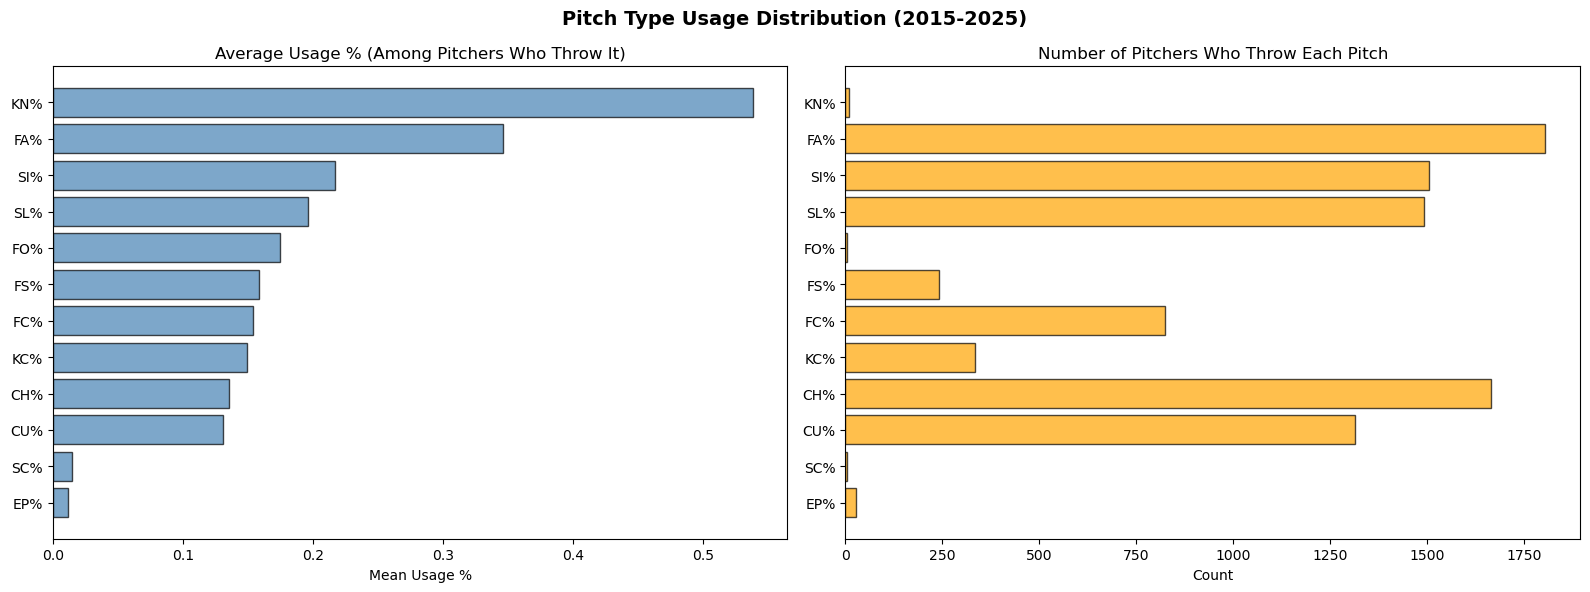

In [35]:
# Pitch type usage visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Average usage among pitchers who throw each pitch
usage_df_sorted = usage_df.sort_values('Mean Usage', ascending=True)
axes[0].barh(usage_df_sorted.index, usage_df_sorted['Mean Usage'], 
             color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Average Usage % (Among Pitchers Who Throw It)')
axes[0].set_xlabel('Mean Usage %')

# Number of pitchers who throw each pitch
axes[1].barh(usage_df_sorted.index, usage_df_sorted['Pitchers Who Throw It'],
             color='orange', edgecolor='black', alpha=0.7)
axes[1].set_title('Number of Pitchers Who Throw Each Pitch')
axes[1].set_xlabel('Count')

plt.suptitle('Pitch Type Usage Distribution (2015-2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../Outputs/pitch_usage.png', dpi=150, bbox_inches='tight')
plt.show()

### Velocity distributions by pitch type

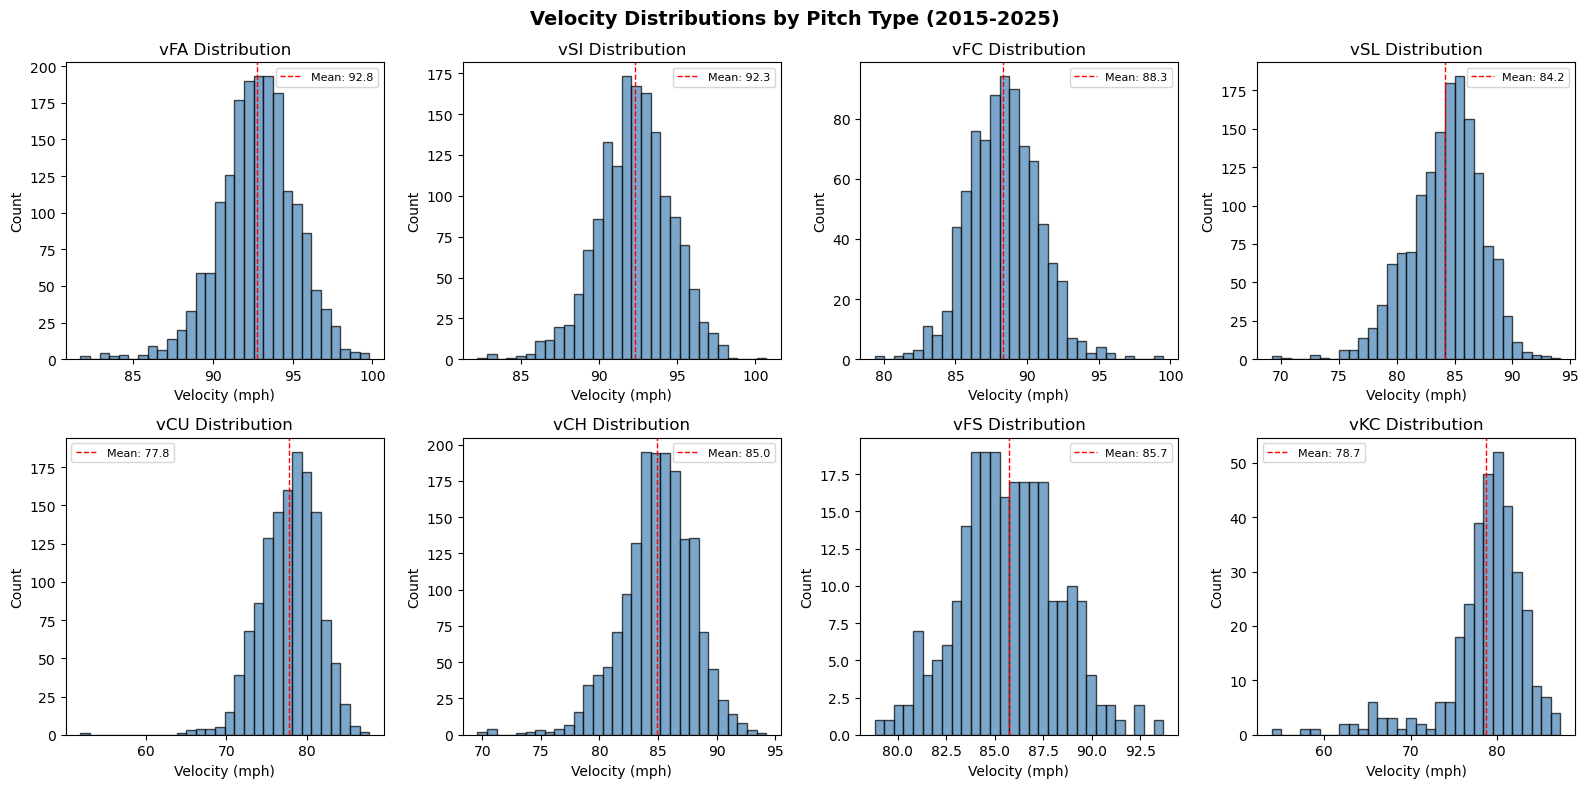

In [36]:
# Velocity distributions by pitch type
vel_cols = ['vFA', 'vSI', 'vFC', 'vSL', 'vCU', 'vCH', 'vFS', 'vKC']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, (col, ax) in enumerate(zip(vel_cols, axes.flatten())):
    data = master[col].dropna()
    ax.hist(data, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel('Velocity (mph)')
    ax.set_ylabel('Count')
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1, 
               label=f'Mean: {data.mean():.1f}')
    ax.legend(fontsize=8)

plt.suptitle('Velocity Distributions by Pitch Type (2015-2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../Outputs/velocity_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
# Velocity summary table
vel_cols = ['vFA', 'vSI', 'vFC', 'vSL', 'vCU', 'vCH', 'vFS', 'vKC']

vel_summary = []
for col in vel_cols:
    data = master[col].dropna()
    vel_summary.append({
        'Pitch': col,
        'Mean (mph)': round(data.mean(), 1),
        'Min (mph)': round(data.min(), 1),
        'Max (mph)': round(data.max(), 1),
        'Std': round(data.std(), 1),
        'Pitchers': len(data)
    })

vel_df = pd.DataFrame(vel_summary).set_index('Pitch')
print(vel_df.to_string())

       Mean (mph)  Min (mph)  Max (mph)  Std  Pitchers
Pitch                                                 
vFA          92.8       81.7       99.8  2.4      1809
vSI          92.3       82.2      100.7  2.3      1510
vFC          88.3       79.4       99.5  2.4       826
vSL          84.2       69.2       94.1  3.1      1496
vCU          77.8       51.8       87.8  3.5      1314
vCH          85.0       69.6       94.2  3.0      1665
vFS          85.7       78.8       93.7  2.6       241
vKC          78.7       53.9       87.3  4.8       335


### Spin rate distributions by pitch type

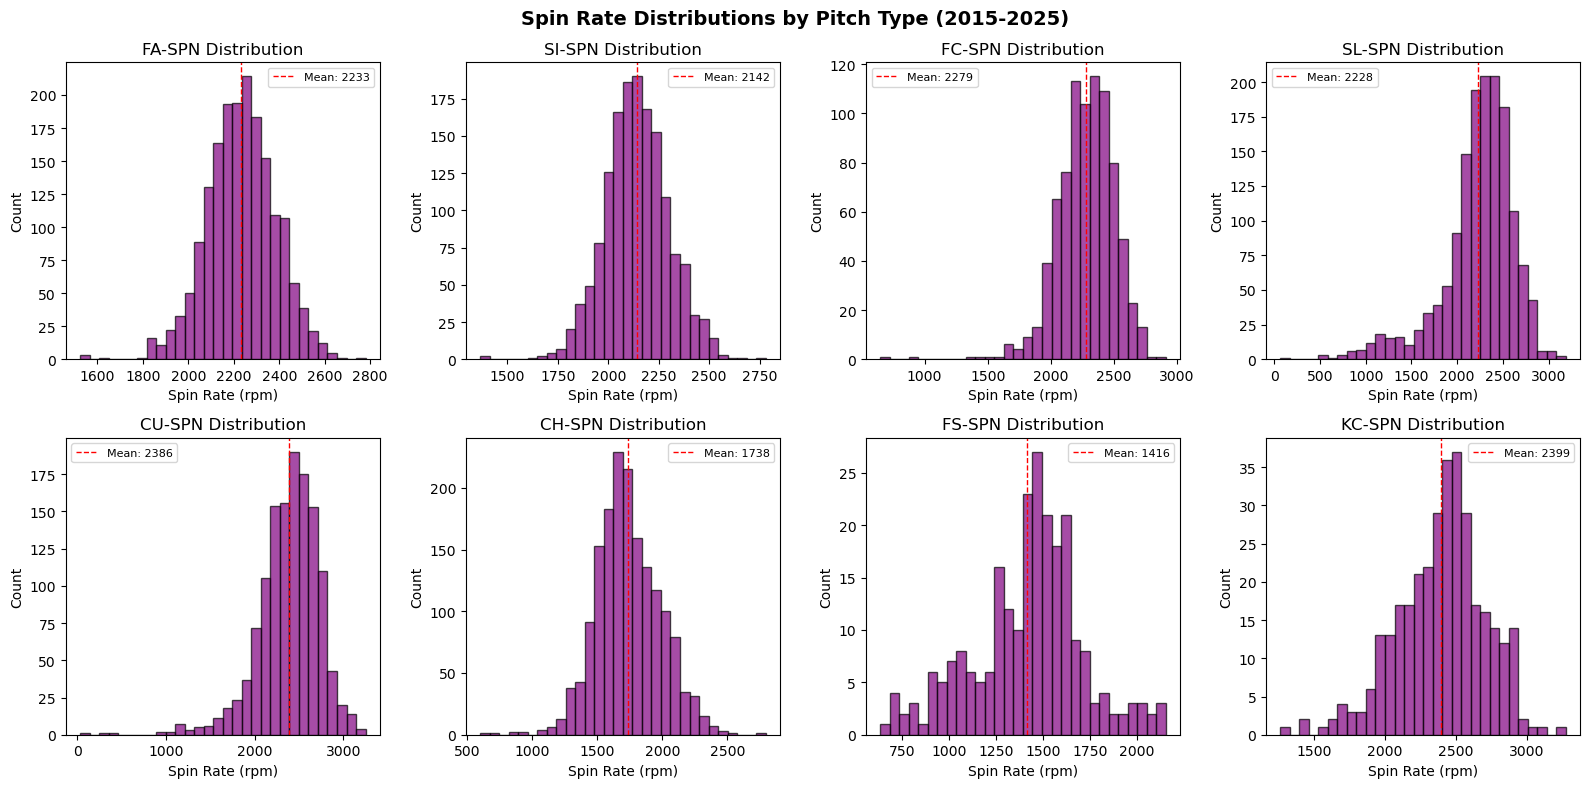

In [42]:
# Spin rate distributions by pitch type
spin_cols = ['FA-SPN', 'SI-SPN', 'FC-SPN', 'SL-SPN', 'CU-SPN', 'CH-SPN', 'FS-SPN', 'KC-SPN']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, (col, ax) in enumerate(zip(spin_cols, axes.flatten())):
    data = master[col].dropna()
    ax.hist(data, bins=30, color='purple', edgecolor='black', alpha=0.7)
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel('Spin Rate (rpm)')
    ax.set_ylabel('Count')
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1,
               label=f'Mean: {data.mean():.0f}')
    ax.legend(fontsize=8)

plt.suptitle('Spin Rate Distributions by Pitch Type (2015-2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../Outputs/spin_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
# Replace 0 spin rates with NaN (physically impossible)
spin_cols = ['FA-SPN', 'SI-SPN', 'FC-SPN', 'SL-SPN', 'CU-SPN', 'CH-SPN', 'FS-SPN', 'KC-SPN']

for col in spin_cols:
    master[col] = master[col].replace(0, float('nan'))

# Verify
for col in spin_cols:
    zeros = (master[col] == 0).sum()
    print(f'{col}: {zeros} zero values remaining')

# Save updated master
master.to_csv('../Data/Processed/master_dataset.csv', index=False)
print('\nMaster dataset saved with corrected spin rates')

FA-SPN: 0 zero values remaining
SI-SPN: 0 zero values remaining
FC-SPN: 0 zero values remaining
SL-SPN: 0 zero values remaining
CU-SPN: 0 zero values remaining
CH-SPN: 0 zero values remaining
FS-SPN: 0 zero values remaining
KC-SPN: 0 zero values remaining

Master dataset saved with corrected spin rates


In [44]:
# Spin rate summary table
spin_cols = ['FA-SPN', 'SI-SPN', 'FC-SPN', 'SL-SPN', 'CU-SPN', 'CH-SPN', 'FS-SPN', 'KC-SPN']

spin_summary = []
for col in spin_cols:
    data = master[col].dropna()
    spin_summary.append({
        'Pitch': col,
        'Mean (rpm)': round(data.mean(), 0),
        'Min (rpm)': round(data.min(), 0),
        'Max (rpm)': round(data.max(), 0),
        'Std': round(data.std(), 0),
        'Pitchers': len(data)
    })

spin_df = pd.DataFrame(spin_summary).set_index('Pitch')
print(spin_df.to_string())

        Mean (rpm)  Min (rpm)  Max (rpm)    Std  Pitchers
Pitch                                                    
FA-SPN      2233.0     1524.0     2779.0  150.0      1809
SI-SPN      2142.0     1365.0     2780.0  157.0      1510
FC-SPN      2279.0      649.0     2910.0  224.0       826
SL-SPN      2228.0       68.0     3185.0  393.0      1493
CU-SPN      2386.0       31.0     3252.0  348.0      1313
CH-SPN      1738.0      599.0     2794.0  245.0      1665
FS-SPN      1416.0      632.0     2152.0  295.0       241
KC-SPN      2399.0     1261.0     3277.0  312.0       334


### H-Movement distributions by pitch type

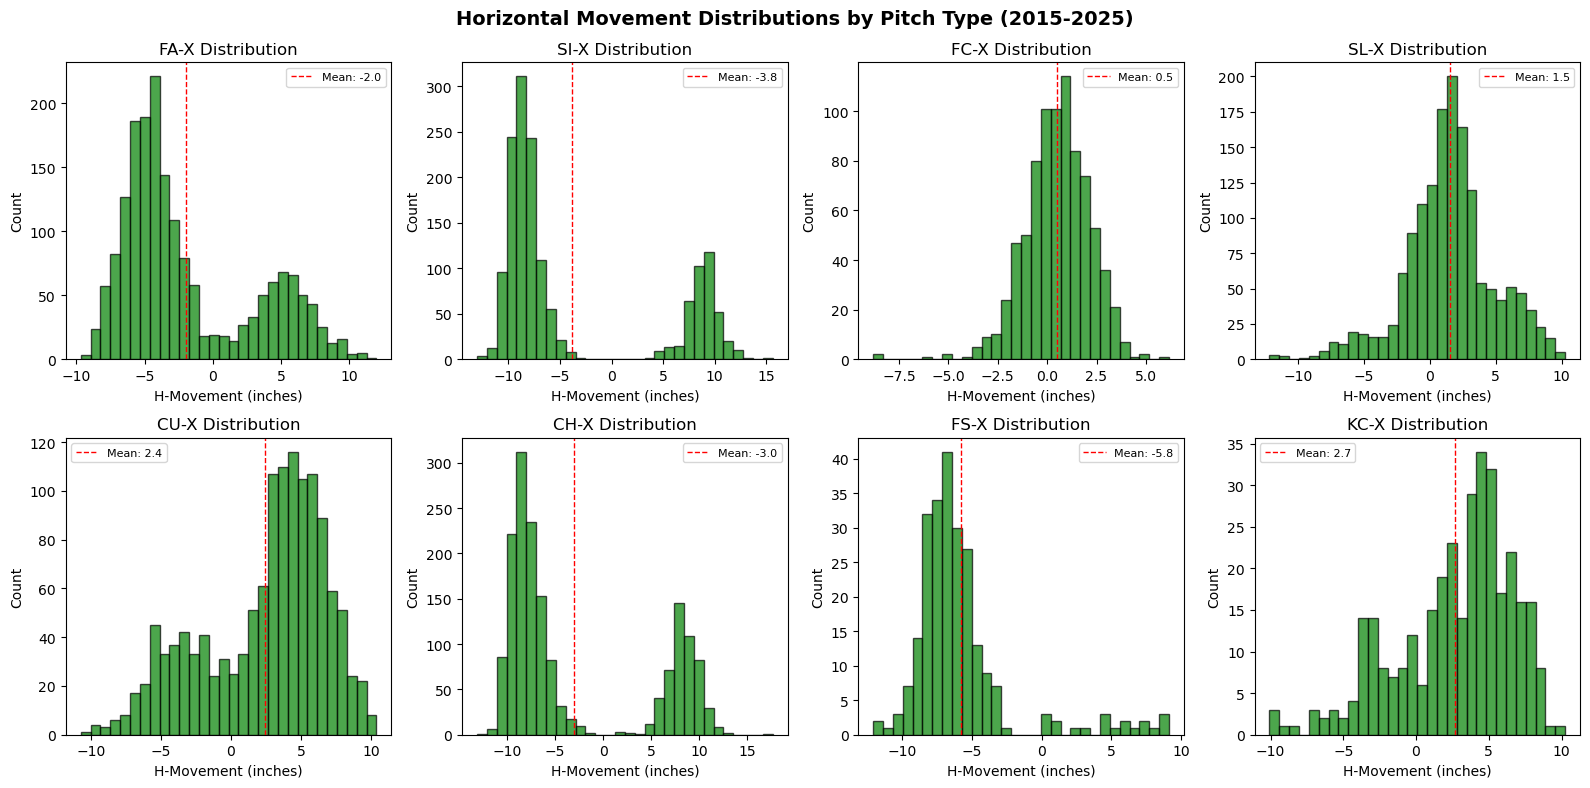

       Mean (in)  Min (in)  Max (in)  Std  Pitchers
Pitch                                              
FA-X        -2.0      -9.7      12.0  4.8      1809
SI-X        -3.8     -13.0      15.6  7.8      1510
FC-X         0.5      -8.8       6.2  1.6       826
SL-X         1.5     -12.2      10.3  3.4      1496
CU-X         2.4     -10.7      10.4  4.4      1314
CH-X        -3.0     -13.1      17.6  7.6      1665
FS-X        -5.8     -12.1       9.1  3.7       241
KC-X         2.7     -10.1      10.3  4.0       335


In [46]:
# H-Movement distributions by pitch type
hmove_cols = ['FA-X', 'SI-X', 'FC-X', 'SL-X', 'CU-X', 'CH-X', 'FS-X', 'KC-X']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, (col, ax) in enumerate(zip(hmove_cols, axes.flatten())):
    data = master[col].dropna()
    ax.hist(data, bins=30, color='green', edgecolor='black', alpha=0.7)
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel('H-Movement (inches)')
    ax.set_ylabel('Count')
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1,
               label=f'Mean: {data.mean():.1f}')
    ax.legend(fontsize=8)

plt.suptitle('Horizontal Movement Distributions by Pitch Type (2015-2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../Outputs/hmove_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
hmove_summary = []
for col in hmove_cols:
    data = master[col].dropna()
    hmove_summary.append({
        'Pitch': col,
        'Mean (in)': round(data.mean(), 1),
        'Min (in)': round(data.min(), 1),
        'Max (in)': round(data.max(), 1),
        'Std': round(data.std(), 1),
        'Pitchers': len(data)
    })

hmove_df = pd.DataFrame(hmove_summary).set_index('Pitch')
print(hmove_df.to_string())

### V-Movement distributions by pitch type

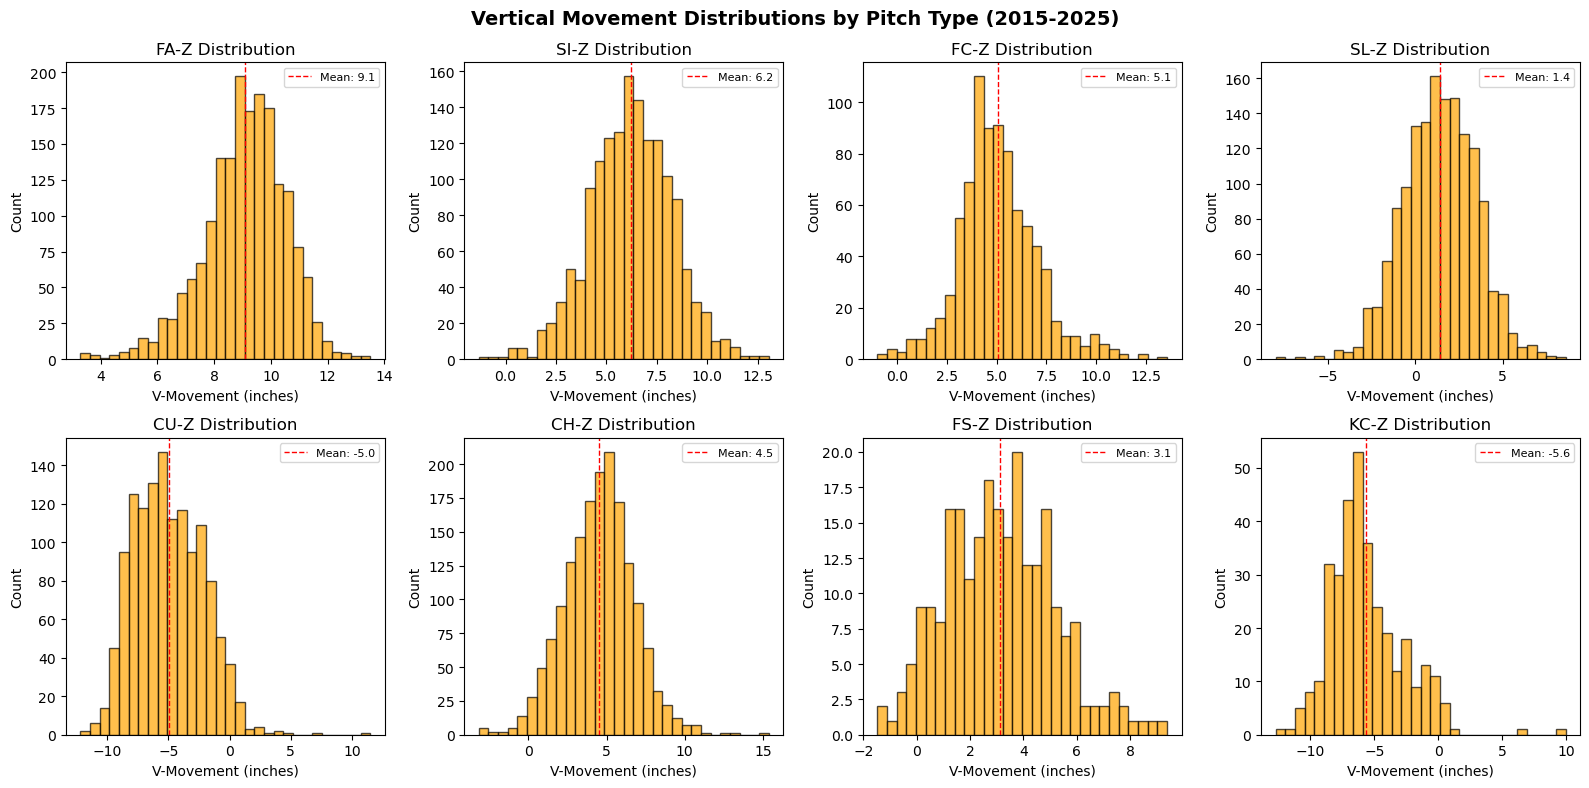

       Mean (in)  Min (in)  Max (in)  Std  Pitchers
Pitch                                              
FA-Z         9.1       3.3      13.5  1.4      1809
SI-Z         6.2      -1.3      13.0  2.0      1510
FC-Z         5.1      -1.0      13.6  2.0       826
SL-Z         1.4      -8.0       8.6  2.1      1496
CU-Z        -5.0     -12.2      11.5  2.8      1314
CH-Z         4.5      -3.2      15.4  2.2      1665
FS-Z         3.1      -1.5       9.4  2.0       241
KC-Z        -5.6     -12.7       9.9  2.9       335


In [47]:
# V-Movement distributions by pitch type
vmove_cols = ['FA-Z', 'SI-Z', 'FC-Z', 'SL-Z', 'CU-Z', 'CH-Z', 'FS-Z', 'KC-Z']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, (col, ax) in enumerate(zip(vmove_cols, axes.flatten())):
    data = master[col].dropna()
    ax.hist(data, bins=30, color='orange', edgecolor='black', alpha=0.7)
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel('V-Movement (inches)')
    ax.set_ylabel('Count')
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1,
               label=f'Mean: {data.mean():.1f}')
    ax.legend(fontsize=8)

plt.suptitle('Vertical Movement Distributions by Pitch Type (2015-2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../Outputs/vmove_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
vmove_summary = []
for col in vmove_cols:
    data = master[col].dropna()
    vmove_summary.append({
        'Pitch': col,
        'Mean (in)': round(data.mean(), 1),
        'Min (in)': round(data.min(), 1),
        'Max (in)': round(data.max(), 1),
        'Std': round(data.std(), 1),
        'Pitchers': len(data)
    })

vmove_df = pd.DataFrame(vmove_summary).set_index('Pitch')
print(vmove_df.to_string())

### How arsenal has changed over time (2015-2025)

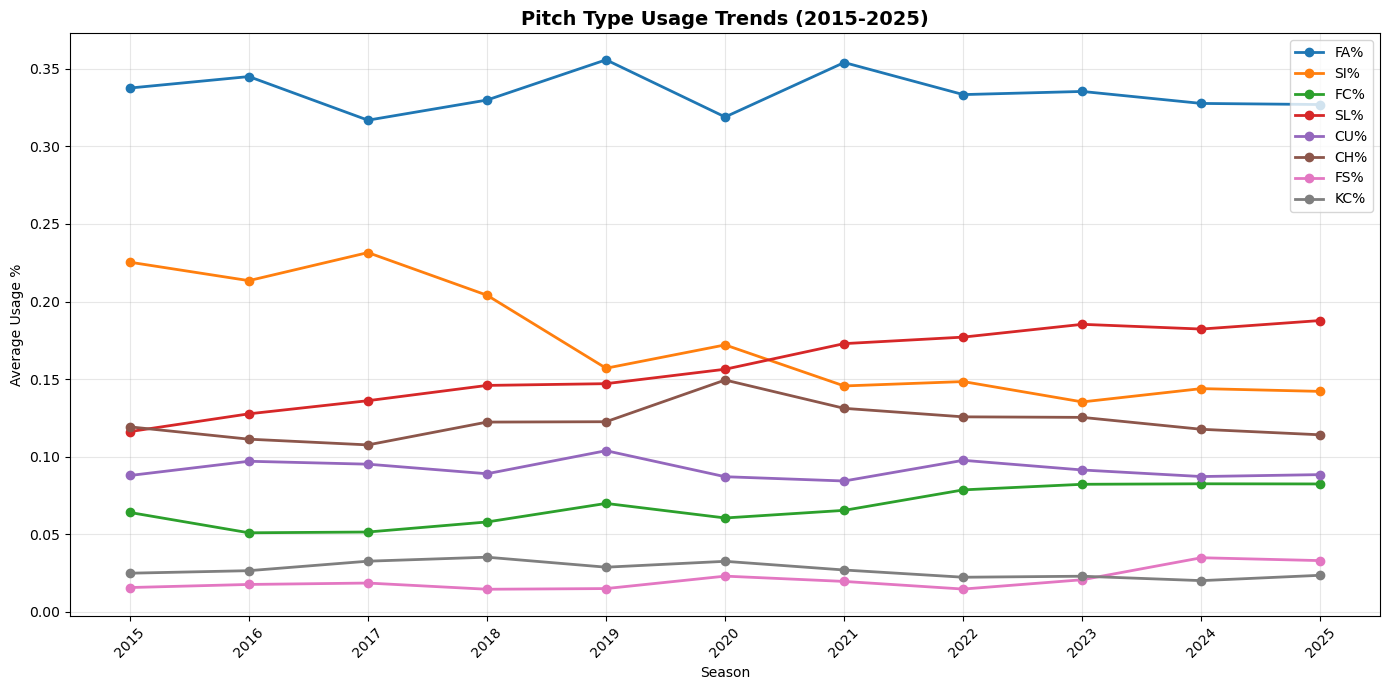

          FA%    SI%    FC%    SL%    CU%    CH%    FS%    KC%
Season                                                        
2015    0.338  0.225  0.064  0.116  0.088  0.119  0.016  0.025
2016    0.345  0.213  0.051  0.128  0.097  0.111  0.018  0.027
2017    0.317  0.232  0.051  0.136  0.095  0.108  0.019  0.033
2018    0.330  0.204  0.058  0.146  0.089  0.122  0.015  0.035
2019    0.356  0.157  0.070  0.147  0.104  0.123  0.015  0.029
2020    0.319  0.172  0.060  0.156  0.087  0.149  0.023  0.033
2021    0.354  0.146  0.065  0.173  0.084  0.131  0.020  0.027
2022    0.333  0.148  0.079  0.177  0.098  0.126  0.015  0.022
2023    0.335  0.135  0.082  0.185  0.091  0.125  0.021  0.023
2024    0.328  0.144  0.083  0.182  0.087  0.118  0.035  0.020
2025    0.327  0.142  0.082  0.188  0.088  0.114  0.033  0.024


In [48]:
# Arsenal trends over time (2015-2025)
pitch_cols = ['FA%', 'SI%', 'FC%', 'SL%', 'CU%', 'CH%', 'FS%', 'KC%']

yearly_usage = master.groupby('Season')[pitch_cols].mean()

plt.figure(figsize=(14, 7))
for col in pitch_cols:
    plt.plot(yearly_usage.index, yearly_usage[col], marker='o', label=col, linewidth=2)

plt.title('Pitch Type Usage Trends (2015-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Average Usage %')
plt.legend(loc='upper right')
plt.xticks(yearly_usage.index, rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../Outputs/arsenal_trends.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print(yearly_usage.round(3).to_string())

## Section 4 - Feature Selection

In [50]:
# Fix string columns
string_cols = ['LOB%', 'GB%', 'HR/FB']
for col in string_cols:
    if master[col].dtype == object:
        master[col] = master[col].str.replace('%', '').astype(float) / 100

# Verify
print(master[['LOB%', 'GB%', 'HR/FB']].dtypes)
print(master[['LOB%', 'GB%', 'HR/FB']].head(3))

LOB%     float64
GB%      float64
HR/FB    float64
dtype: object
       LOB%       GB%     HR/FB
0  0.007277  0.004732  0.000714
1  0.007377  0.002709  0.001397
2  0.006931  0.004402  0.001575


### Correlation heatmap for all performance features (Linear Models)

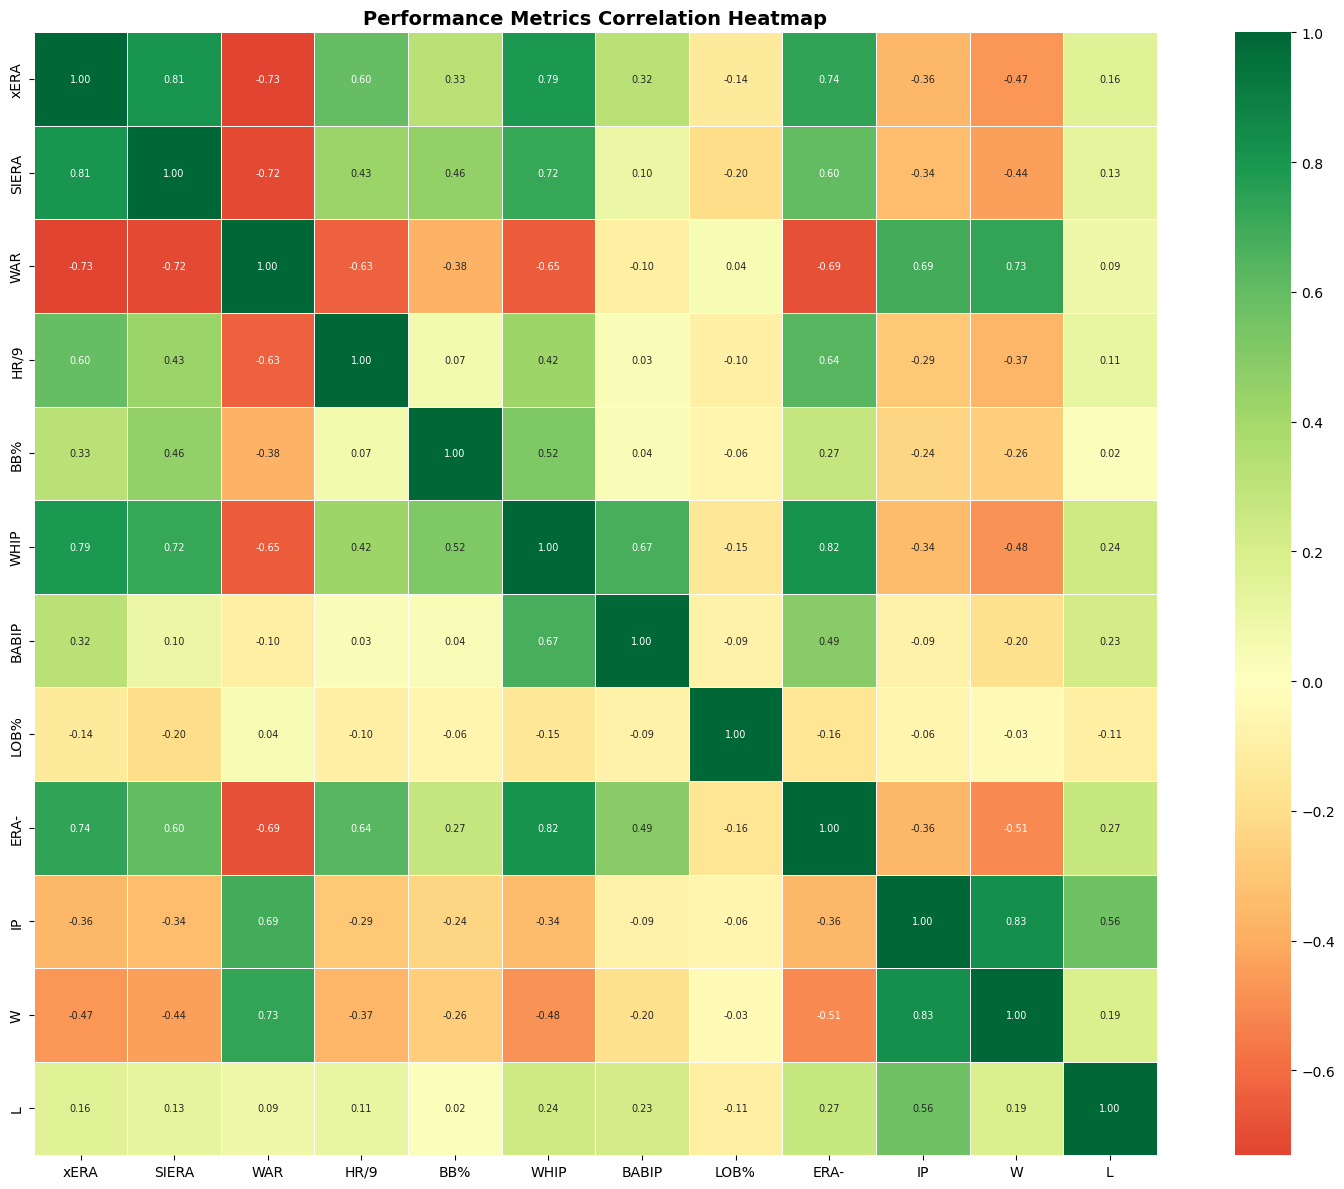

In [82]:
# Correlation heatmap for all performance features
perf_cols = ['xERA','SIERA', 'WAR', 
             'HR/9','BB%',
             'WHIP', 'BABIP', 'LOB%',
             'ERA-','IP', 'W', 'L']

corr_matrix = master[perf_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5,
            annot_kws={'size': 7})

plt.title('Performance Metrics Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../Outputs/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### VIF check for performance features

In [93]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

# VIF check for performance features
perf_features = ['SIERA', 'WAR', 'LOB%',
             'W', 'L' ]

# Drop rows with any nulls in these columns
vif_data = master[perf_features].dropna()

vif_results = pd.DataFrame()
vif_results['Feature'] = perf_features
vif_results['VIF'] = [variance_inflation_factor(vif_data.values, i) 
                       for i in range(len(perf_features))]

print(vif_results.sort_values('VIF', ascending=False).to_string())

  Feature       VIF
3       W  9.340622
0   SIERA  7.049960
4       L  6.887640
1     WAR  5.258774
2    LOB%  1.044371


### Correlation heatmap for all performance features (Tree models)

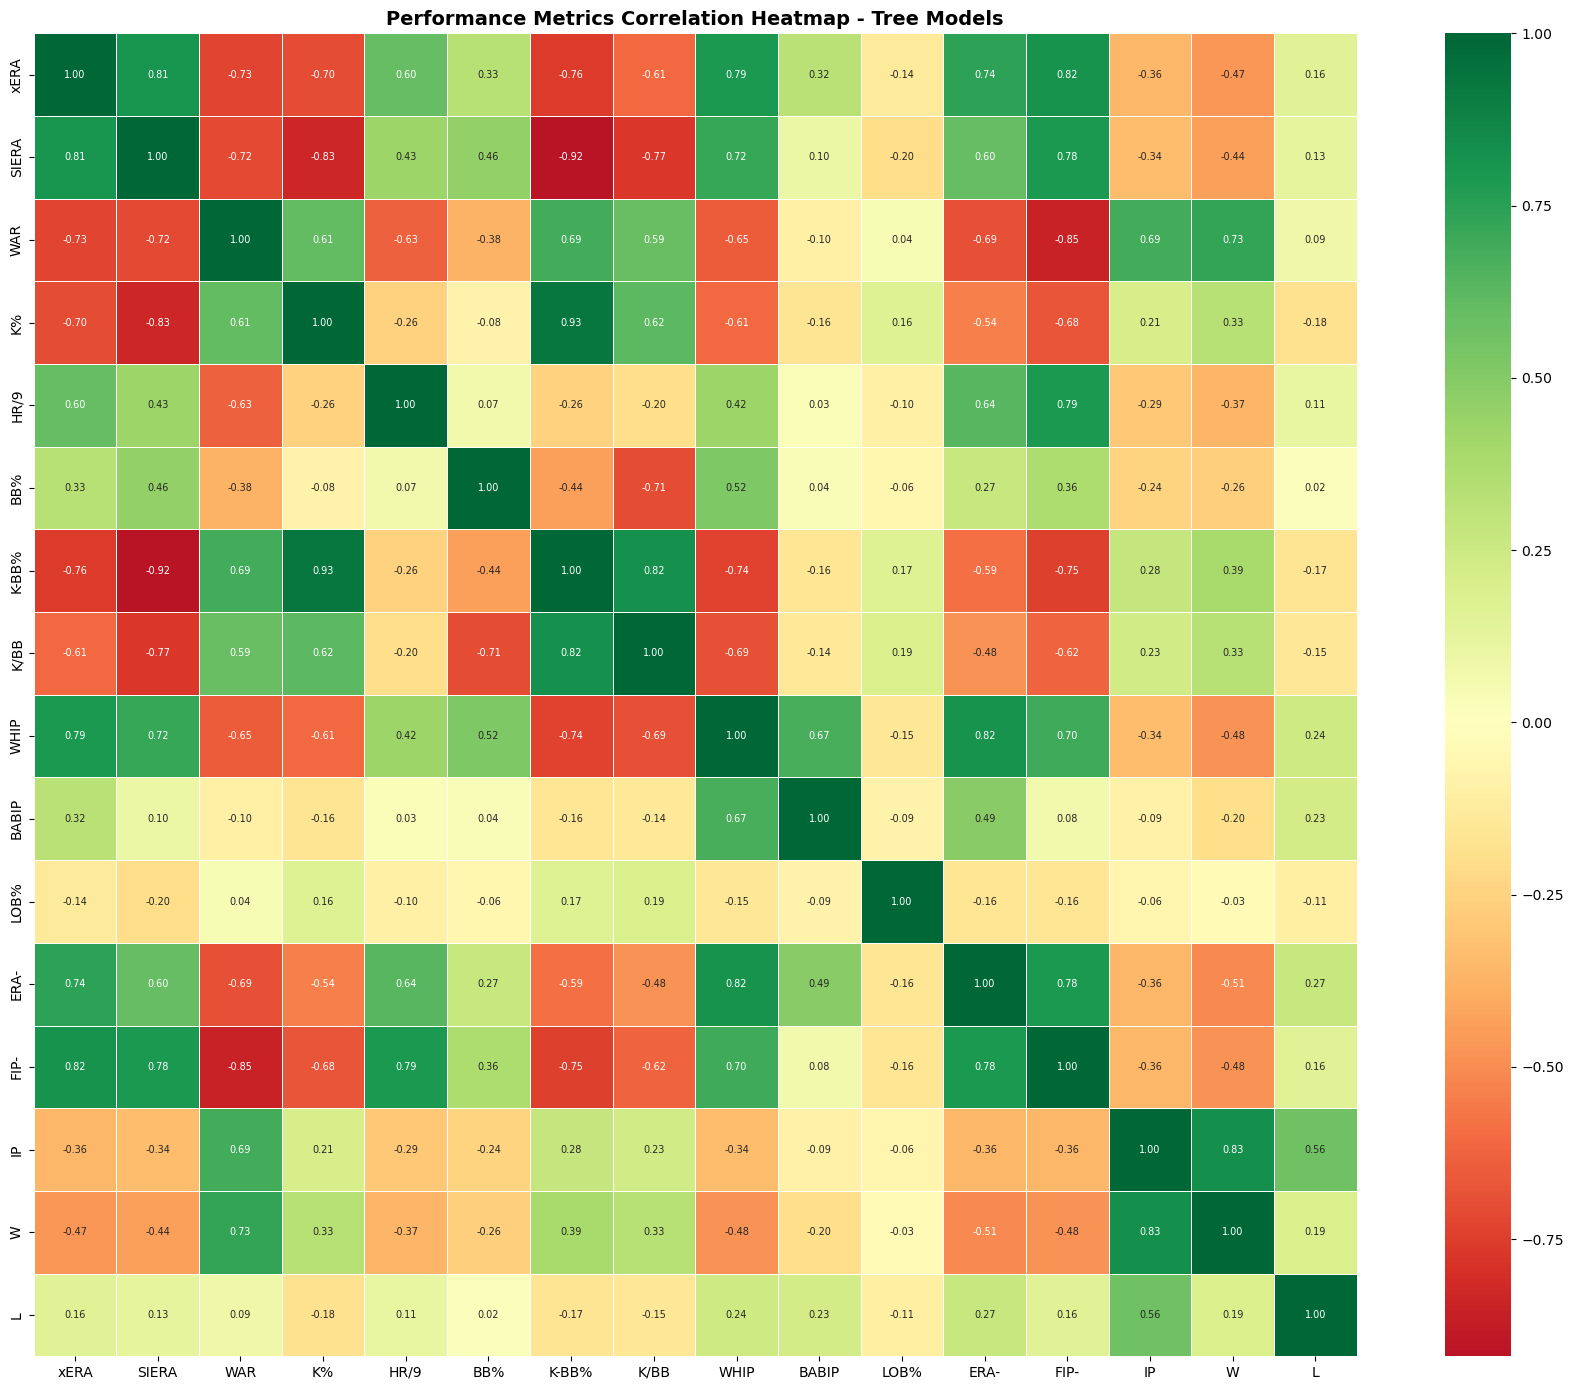

In [102]:
perf_cols = ['xERA', 'SIERA', 'WAR', 
             'K%','HR/9','BB%', 'K-BB%', 'K/BB',
             'WHIP', 'BABIP', 'LOB%',
             'ERA-', 'FIP-','IP', 'W', 'L']

corr_matrix = master[perf_cols].corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, annot_kws={'size': 7})
plt.title('Performance Metrics Correlation Heatmap - Tree Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../Outputs/correlation_heatmap_tree.png', dpi=150, bbox_inches='tight')
plt.show()

### Final feature sets Regression & tree model

In [ ]:
# Final feature sets
linear_features = ['SIERA', 'WAR', 'LOB%', 'W', 'L']

tree_features = ['xERA', 'SIERA', 'WAR', 'K%', 'HR/9', 'BB%', 
                 'K-BB%', 'K/BB', 'WHIP', 'BABIP', 'LOB%',
                 'ERA-', 'FIP-', 'IP', 'W', 'L']

print('Linear features:', len(linear_features), linear_features)
print('Tree features:', len(tree_features), tree_features)

### Features for PCA & Kmeans

In [104]:
arsenal_features = [
    # Pitch usage % - how often each pitch is thrown
    'FA%', 'SI%', 'FC%', 'SL%', 'CU%', 'CH%', 'FS%', 'KC%',
    
    # Velocity - average speed per pitch type
    'vFA', 'vSI', 'vFC', 'vSL', 'vCU', 'vCH', 'vFS', 'vKC',
    
    # Horizontal movement - arm side/glove side break
    'FA-X', 'SI-X', 'FC-X', 'SL-X', 'CU-X', 'CH-X', 'FS-X', 'KC-X',
    
    # Vertical movement - rise/drop
    'FA-Z', 'SI-Z', 'FC-Z', 'SL-Z', 'CU-Z', 'CH-Z', 'FS-Z', 'KC-Z',
    
    # Spin rate - revolutions per minute per pitch type
    'FA-SPN', 'SI-SPN', 'FC-SPN', 'SL-SPN', 'CU-SPN', 'CH-SPN', 'FS-SPN', 'KC-SPN',
    
    # Outcome metrics - what happens as a result of the arsenal
    'GB%',  # Ground ball tendency
    'K%',   # Strikeout tendency
    'BB%'   # Walk tendency
]

print(f'Total arsenal features: {len(arsenal_features)}')

Total arsenal features: 43
